In [1]:
import re
import string

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk import FreqDist
from nltk.util import ngrams

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# NLTK downloads
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
df = pd.read_csv("/content/sample_data/amazon_product_reviews_dataset.csv")

print("Dataset Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Dataset Shape: (1597, 27)
Columns: ['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [3]:
df = df[[
    "brand",
    "name",
    "categories",
    "reviews.title",
    "reviews.text",
    "reviews.rating"
]].copy()

df["reviews.title"] = df["reviews.title"].fillna("")
df["reviews.text"] = df["reviews.text"].fillna("")

df["review_full"] = (
    df["reviews.title"].astype(str) + " " +
    df["reviews.text"].astype(str)
).str.strip()

df = df[df["review_full"].str.len() > 0]
df.head()

,brand,name,categories,reviews.title,reviews.text,reviews.rating,review_full
0,Amazon,Kindle Paperwhite,"Amazon Devices,mazon.co.uk","Paperwhite voyage, no regrets!",I initially had trouble deciding between the p...,5.0,"Paperwhite voyage, no regrets! I initially had..."
1,Amazon,Kindle Paperwhite,"Amazon Devices,mazon.co.uk",One Simply Could Not Ask For More,Allow me to preface this with a little history...,5.0,One Simply Could Not Ask For More Allow me to ...
2,Amazon,Kindle Paperwhite,"Amazon Devices,mazon.co.uk",Great for those that just want an e-reader,I am enjoying it so far. Great for reading. Ha...,4.0,Great for those that just want an e-reader I a...
3,Amazon,Kindle Paperwhite,"Amazon Devices,mazon.co.uk",Love / Hate relationship,I bought one of the first Paperwhites and have...,5.0,Love / Hate relationship I bought one of the f...
4,Amazon,Kindle Paperwhite,"Amazon Devices,mazon.co.uk",I LOVE IT,I have to say upfront - I don't like coroporat...,5.0,I LOVE IT I have to say upfront - I don't like...


In [4]:
df["reviews.rating"] = pd.to_numeric(df["reviews.rating"], errors="coerce")
df = df.dropna(subset=["reviews.rating"])

def map_satisfaction(r):
    if r >= 4:
        return "Satisfied"
    elif r == 3:
        return "Neutral"
    else:
        return "Dissatisfied"

df["Satisfaction"] = df["reviews.rating"].apply(map_satisfaction)
df["Satisfaction"].value_counts()

,count
Satisfaction,
Satisfied,977
Neutral,124
Dissatisfied,76


In [5]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

df["clean_review"] = df["review_full"].apply(clean_text)
df = df[df["clean_review"].str.len() > 0]

df[["review_full", "clean_review", "Satisfaction"]].head()

,review_full,clean_review,Satisfaction
0,"Paperwhite voyage, no regrets! I initially had...",paperwhite voyage regret initially trouble dec...,Satisfied
1,One Simply Could Not Ask For More Allow me to ...,one simply could ask allow preface little hist...,Satisfied
2,Great for those that just want an e-reader I a...,great want ereader enjoying far great reading ...,Satisfied
3,Love / Hate relationship I bought one of the f...,love hate relationship bought one first paperw...,Satisfied
4,I LOVE IT I have to say upfront - I don't like...,love say upfront dont like coroporate hermetic...,Satisfied


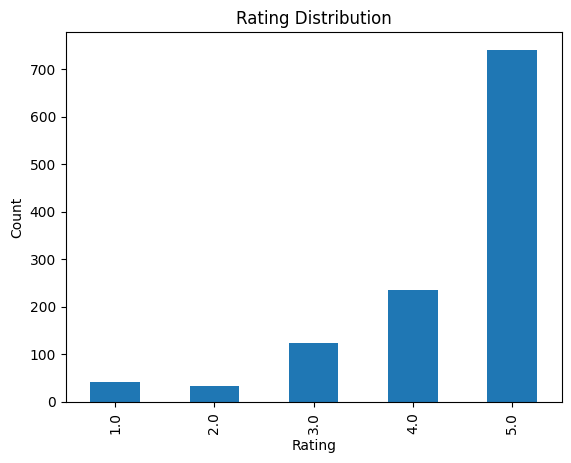

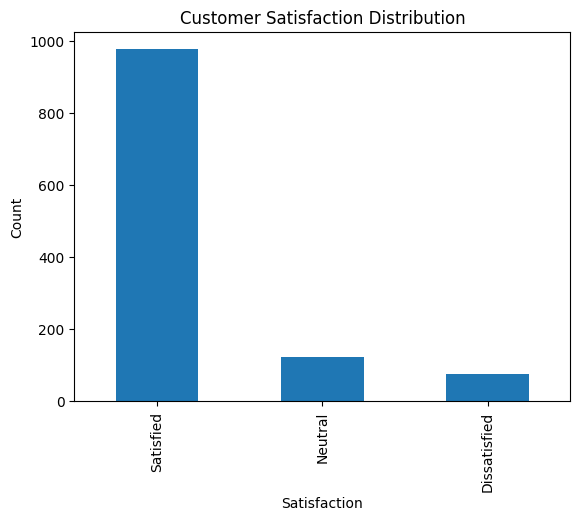

[('great', 898),
 ('amazon', 883),
 ('fire', 861),
 ('like', 769),
 ('kindle', 756),
 ('review', 636),
 ('sound', 618),
 ('use', 616),
 ('one', 608),
 ('tablet', 587),
 ('device', 536),
 ('headphone', 529),
 ('would', 476),
 ('echo', 466),
 ('dont', 456),
 ('tap', 453),
 ('year', 440),
 ('love', 423),
 ('speaker', 421),
 ('work', 419)]

In [6]:
df["reviews.rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

df["Satisfaction"].value_counts().plot(kind="bar")
plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.show()

tokens_all = " ".join(df["clean_review"]).split()
FreqDist(tokens_all).most_common(20)

In [7]:
sia = SentimentIntensityAnalyzer()

df["vader_score"] = df["clean_review"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def vader_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["VADER_Sentiment"] = df["vader_score"].apply(vader_sentiment)
df["VADER_Sentiment"].value_counts()

,count
VADER_Sentiment,
Positive,1101
Negative,54
Neutral,22


In [8]:
X = df["clean_review"]
y = df["Satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8771186440677966

Classification Report:
               precision    recall  f1-score   support

Dissatisfied       0.00      0.00      0.00        15
     Neutral       1.00      0.44      0.61        25
   Satisfied       0.87      1.00      0.93       196

    accuracy                           0.88       236
   macro avg       0.62      0.48      0.51       236
weighted avg       0.83      0.88      0.84       236

Confusion Matrix:
 [[  0   0  15]
 [  0  11  14]
 [  0   0 196]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
df.to_csv("/content/sample_data/amazon_product_reviews_dataset.csv", index=False)

Final file saved successfully
